### Importing Required Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

### Read data and Understand 

In [51]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [53]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_12832\3580352777.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Sales'])


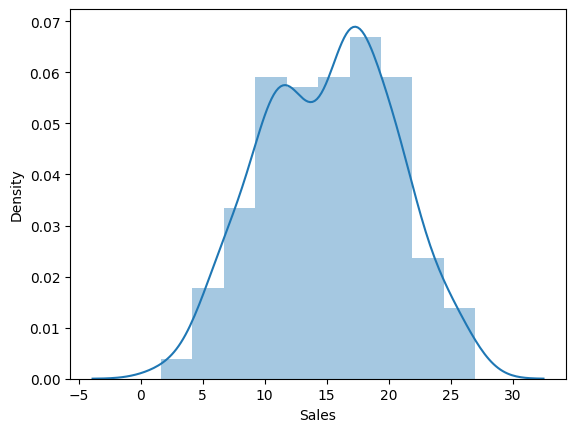

In [54]:
sns.distplot(df['Sales'])
plt.show()

In [55]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [56]:
df.corr()['Sales']

TV           0.901208
Radio        0.349631
Newspaper    0.157960
Sales        1.000000
Name: Sales, dtype: float64

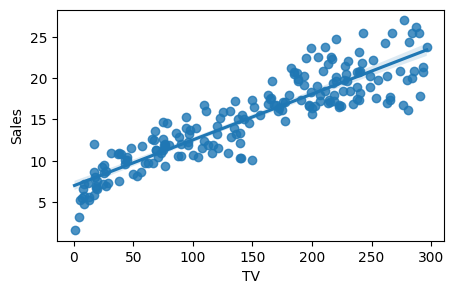

In [57]:
plt.figure(figsize=[5,3])
sns.regplot(data=df,x = df['TV'], y = df['Sales'])
plt.show()

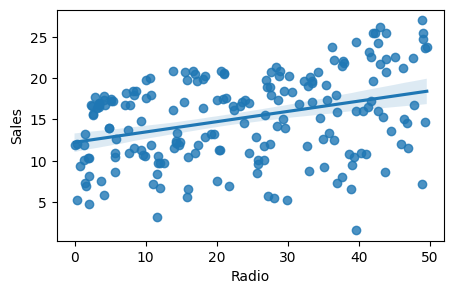

In [58]:
plt.figure(figsize=[5,3])
sns.regplot(data=df,x = df['Radio'], y = df['Sales'])
plt.show()

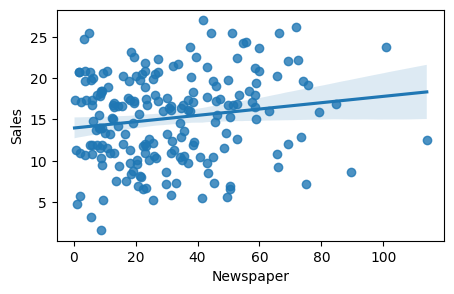

In [59]:
plt.figure(figsize=[5,3])
sns.regplot(data=df,x = df['Newspaper'], y = df['Sales'])
plt.show()

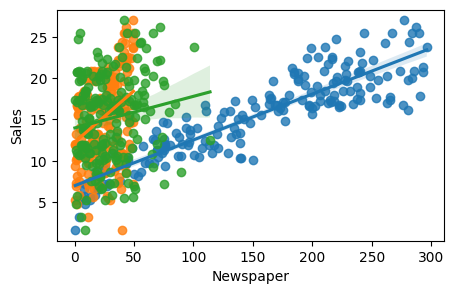

In [60]:
plt.figure(figsize=[5,3])
sns.regplot(data=df,x = df['TV'], y = df['Sales'])
sns.regplot(data=df,x = df['Radio'], y = df['Sales'])
sns.regplot(data=df,x = df['Newspaper'], y = df['Sales'])
plt.show()

### split data into train and test

In [61]:
X = df.drop(columns = 'Sales')
y = df['Sales']

In [62]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [63]:
y[:5]

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

In [64]:
# train test split
Xtrain,Xtest,ytrain,ytest =  train_test_split(X,y,test_size=0.2,random_state=1)

### Model1

In [65]:
# instance of LinearRegression
lr = LinearRegression()

# fit the model
lr.fit(Xtrain,ytrain)

# predcit
ypred = lr.predict(Xtest)

In [66]:
# r2_score
r2_score(ytest,ypred)

0.8747226291661847

In [76]:
# mae
print(f'mean_absolute_error : {mean_absolute_error(ytest,ypred)}')

#mse
print(f'mean_squared_error : {mean_squared_error(ytest,ypred)}')

#rmse
print(f'root_mean_squared_error : {np.sqrt(mean_squared_error(ytest,ypred))}')

mean_absolute_error : 1.2754390912939684
mean_squared_error : 2.409333612892369
root_mean_squared_error : 1.552202825951676


In [67]:
# plt.figure(figsize=[5,3])
# plt.scatter(Xtrain,ytrain,c='green')
# plt.scatter(Xtest,ytest,c='orange')
# plt.plot(Xtest,ypred,c='blue')
# plt.show()

In [72]:
!pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 19.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [73]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------------- ------------------- 5.0/9.8 MB 23.2 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 26.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
# importing statsmodels
import statsmodels.api as sm

# Input Features
X = df.drop(columns='Sales')

# Output Features 
y = df['Sales']

# Add a constant (Independent Intercept)
X = sm.add_constant(X) # passing a constant 

# Fitting model
model = sm.OLS(y , X).fit()

- t-test and pvalue are used to assess the significance of the individual co-efficient (slope) of all the independent in the model

- In null hypothesis, we say that all the co-efficient are equal to zero indicating no effect on the dependent variable

- In alternate hypothesis, we say that all the co-efficient are not equal to zero indicating there is a  effect on the dependent variable

- A low p-value (<0.05) indicates that we have sufficient evidence to reject null hypothesis means, we can say that co-efficient are significant and different from zero

- So we perform t-test to determine the p-value.

In [78]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Tue, 31 Dec 2024   Prob (F-statistic):           8.13e-99
Time:                        18:10:52   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

### Conclusion
- In this model Newspaper has more p>|t|. So as a Result we have to eliminate the `Newspaper` feature

### Model2


In [91]:
# split data into X and y
X = df.drop(columns=['Newspaper','Sales'])
y = df['Sales']

In [92]:
# train test split
Xtrain,Xtest,ytrain,ytest =  train_test_split(X,y,test_size=0.2,random_state=1)

In [93]:
# instance of LinearRegression
lr = LinearRegression()

# fit the model
lr.fit(Xtrain,ytrain)

# predcit
ypred = lr.predict(Xtest)

In [94]:
# r2_score
r2_score(ytest,ypred)

0.8749222345136187

In [95]:
# mae
print(f'mean_absolute_error : {mean_absolute_error(ytest,ypred)}')

#mse
print(f'mean_squared_error : {mean_squared_error(ytest,ypred)}')

#rmse
print(f'root_mean_squared_error : {np.sqrt(mean_squared_error(ytest,ypred))}')

mean_absolute_error : 1.2715087162436318
mean_squared_error : 2.4054948040980504
root_mean_squared_error : 1.5509657649664774


In [96]:
# importing statsmodels
import statsmodels.api as sm

# Input Features
X = df[['TV','Radio']]

# Output Features 
y = df['Sales']

# Add a constant (Independent Intercept)
X = sm.add_constant(X) # passing a constant 

# Fitting model
model = sm.OLS(y , X).fit()

In [97]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Tue, 31 Dec 2024   Prob (F-statistic):          2.39e-100
Time:                        18:29:46   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6309      0.290     15.952      0.0